[10:42:42] Initializing Normalizer


Inertial Fragment Matching happening...
Cuttable bond indices: [0, 1, 7, 12, 13, 20, 29, 36]
Iter 0: sizes = [38]
Iter 1: sizes = [21, 17]
Iter 2: sizes = [13, 8, 17]
Iter 3: sizes = [13, 8, 7, 10]
All fragments within size window; stopping.
Inertial Fragment Matching happened!


*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBond

AVERAGE SHAPE SIMILARITY - 0.75
VALID SAMPLES - 80.0 %


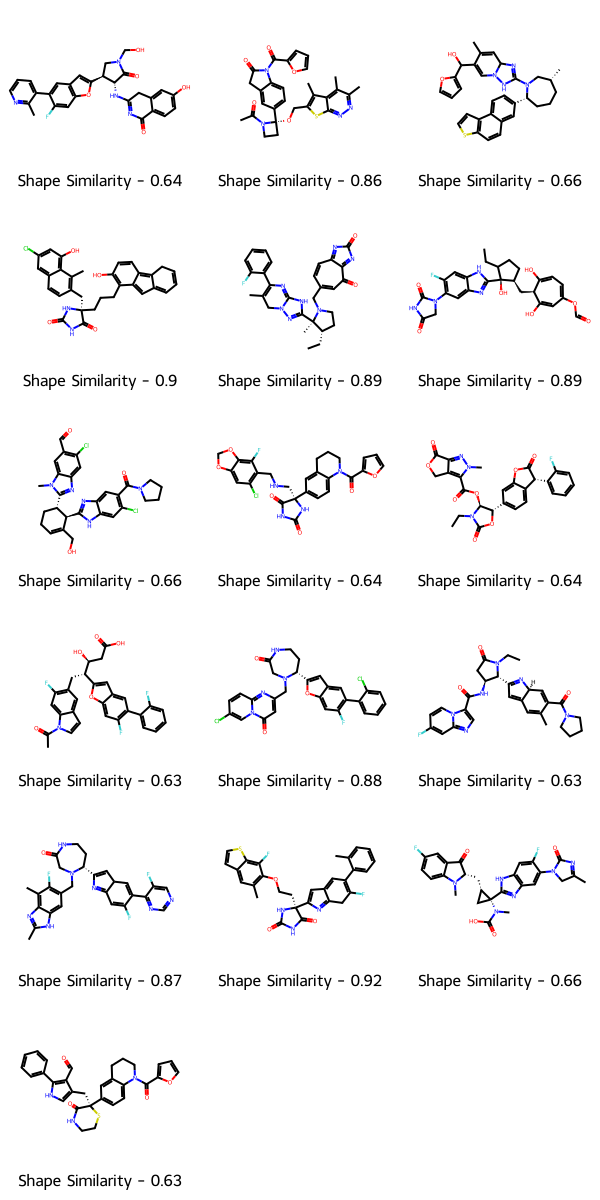

In [1]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

from src.mlconfgen import evaluate_samples, MLConformerGenerator
from src.mlconfgen.inertial_fragment_matching import inertial_fragment_matching, predict_bonds_openbabel
from src.mlconfgen.utils.mol_utils import prepare_masks, redefine_bonds, prepare_adj_mat_seer_input
from src.mlconfgen.utils.standardizer import standardize_mol

RDLogger.DisableLog('rdApp.*')

generator = MLConformerGenerator(
                                 edm_weights="./licensed_edm_moi_chembl_6_39_final.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device="cpu",
                                 diffusion_steps=100, # Light generation for debugging
                                )

ref_mol = Chem.MolFromMolFile('38_atoms_example.mol')
# ref_mol = Chem.MolFromMolFile('./assets/demo_files/ceyyag.mol')

n_atoms = ref_mol.GetNumHeavyAtoms()

print("Inertial Fragment Matching happening...")

N_SAMPLES = 20

final_mols = inertial_fragment_matching(
                                ref_mol=ref_mol,
                                n_samples=N_SAMPLES,
                                generator=generator,  # MLConformerGenerator object
                                resample_steps=0,  # resample steps
                                diffusion_steps_merging=10,  # diffusion steps for merging approx 10% from model diffusion steps
                                min_frag_size=6,  # Minimal fragment size in number of heavy atoms
                                max_frag_size=15,  # Maximal fragment size in number of heavy atoms
                                max_n_atoms_final=n_atoms,  # Max n_atoms in the final molecule
                                min_n_atoms_final=n_atoms,  # Min n_atoms in the final molecule
                                max_iter=200,  # Max iterations for molecule splitting
                                verbose=True,  # Verbose flag
    
)

print("Inertial Fragment Matching happened!")


obabel_mols = []

# Switched to deterministic bond prediction
for mol in final_mols:
    f_mol = predict_bonds_openbabel(mol, optimize_geometry=False)
    if f_mol:
        obabel_mols.append(f_mol)

_, std_samples = evaluate_samples(ref_mol, obabel_mols)

# Display results
mols = []
legends = []
average_shape_similarity = 0
for sample in std_samples:
    mol = Chem.MolFromMolBlock(sample['mol_block'])
    mol = Chem.MolFromSmiles(Chem.MolToSmiles(mol))
    mol.SetProp("Shape_Tanimoto", str(sample['shape_tanimoto']))
    mols.append(mol)
    legends.append(f"Shape Similarity - {round(sample['shape_tanimoto'], 2)}")
    average_shape_similarity += round(sample['shape_tanimoto'], 2)

average_shape_similarity = average_shape_similarity / len(std_samples)
print(f"AVERAGE SHAPE SIMILARITY - {average_shape_similarity}")
print(f"VALID SAMPLES - {round(len(std_samples) / N_SAMPLES, 2) * 100} %")
    
Draw.MolsToGridImage(mols, legends=legends)

